# 🌳 Árboles de Decisión — Dataset Iris
**Diplomado en Redes Neuronales y Deep Learning**

Este notebook cubre:
1. Carga y exploración del dataset
2. Clasificación total de los datos
3. Modelo base + comparativa depth=1 vs depth=None
4. Matriz de correlación y limpieza del dataset
5. Modelo optimizado con datos limpios

---
## 📦 1. Importaciones y carga del dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Cargamos el dataset Iris
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
class_names = iris.target_names

# Convertimos a DataFrame para trabajar más cómodo
df = pd.DataFrame(X, columns=feature_names)
df['especie'] = pd.Categorical.from_codes(iris.target, class_names)

print("Primeras 5 filas:")
display(df.head())
print(f"\nForma del dataset: {df.shape}")
print(f"Clases: {class_names}")

Primeras 5 filas:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),especie
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Forma del dataset: (150, 5)
Clases: ['setosa' 'versicolor' 'virginica']


---
## 📊 2. Clasificación total de los datos

Antes de entrenar, siempre conviene conocer bien nuestros datos:
- Cuántos registros hay por clase
- Si el dataset está **balanceado** (mismo número de muestras por clase)
- Estadísticas descriptivas de cada característica

In [3]:
# --- 2.1 Distribución de clases ---
print("=" * 45)
print("  CLASIFICACIÓN TOTAL DE LOS DATOS")
print("=" * 45)

conteo = df['especie'].value_counts()
print("\nConteo por especie:")
print(conteo)
print(f"\nTotal de muestras: {len(df)}")
print(f"Dataset balanceado: {'✅ Sí' if conteo.std() == 0 else '❌ No'}")

# --- 2.2 Estadísticas descriptivas ---
print("\nEstadísticas descriptivas:")
display(df.describe().round(2))

  CLASIFICACIÓN TOTAL DE LOS DATOS

Conteo por especie:
especie
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Total de muestras: 150
Dataset balanceado: ✅ Sí

Estadísticas descriptivas:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


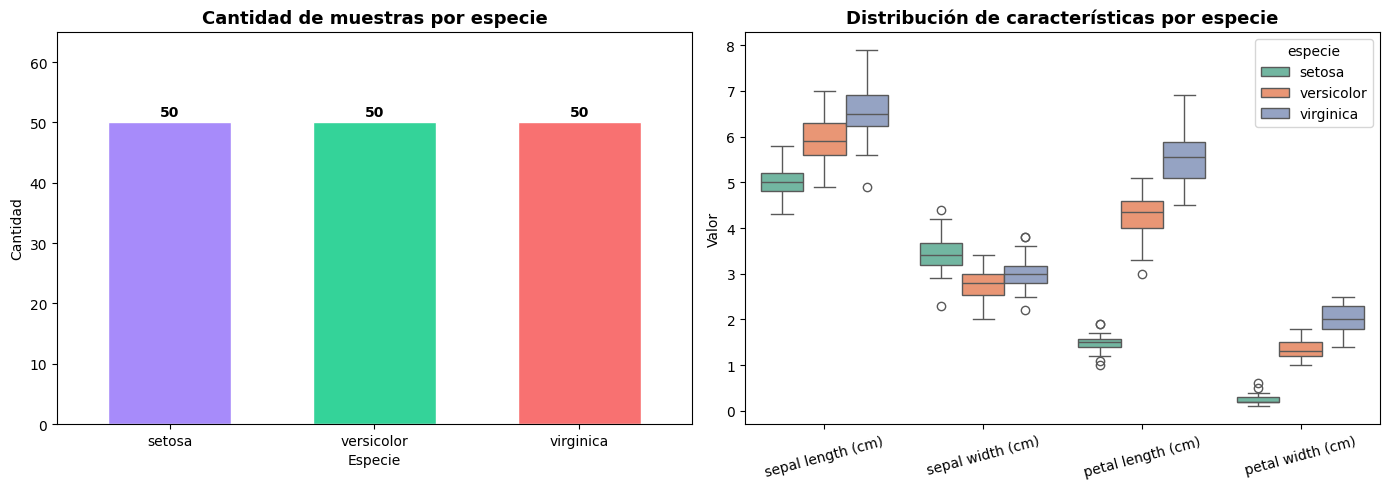


💡 Observación: El dataset está perfectamente balanceado (50 muestras por clase).
   Esto es ideal para entrenar modelos, ya que no habrá sesgo hacia ninguna clase.


In [4]:
# --- 2.3 Visualización de la distribución por clase ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
conteo.plot(kind='bar', ax=axes[0], color=['#a78bfa', '#34d399', '#f87171'],
            edgecolor='white', width=0.6)
axes[0].set_title('Cantidad de muestras por especie', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Especie')
axes[0].set_ylabel('Cantidad')
axes[0].set_ylim(0, 65)
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(conteo):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Boxplot por característica y especie
df_melt = df.melt(id_vars='especie', var_name='Característica', value_name='Valor')
sns.boxplot(data=df_melt, x='Característica', y='Valor', hue='especie',
            palette='Set2', ax=axes[1])
axes[1].set_title('Distribución de características por especie', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('clasificacion_datos.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n💡 Observación: El dataset está perfectamente balanceado (50 muestras por clase).")
print("   Esto es ideal para entrenar modelos, ya que no habrá sesgo hacia ninguna clase.")

---
## 🌲 3. División y modelo base (max_depth=8)

In [5]:
# División train/test (70% entrenamiento, 30% prueba)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Datos de entrenamiento: {X_train.shape[0]} muestras")
print(f"Datos de prueba:        {X_test.shape[0]} muestras")

# Modelo base
arbol_base = DecisionTreeClassifier(max_depth=8, random_state=42)
arbol_base.fit(X_train, y_train)

y_pred_base = arbol_base.predict(X_test)
acc_base = accuracy_score(y_test, y_pred_base)

print(f"\n📌 Modelo base (max_depth=8)")
print(f"   Precisión en test: {acc_base * 100:.2f}%")
print(f"   Profundidad real del árbol: {arbol_base.get_depth()}")
print(f"   Número de nodos hoja: {arbol_base.get_n_leaves()}")

Datos de entrenamiento: 105 muestras
Datos de prueba:        45 muestras

📌 Modelo base (max_depth=8)
   Precisión en test: 100.00%
   Profundidad real del árbol: 6
   Número de nodos hoja: 10


---
## 🔬 4. Comparativa: depth=1 vs depth=None

### ¿Qué representa la profundidad?
- **depth=1**: El árbol solo puede hacer **una pregunta** (un split). Muy simple, puede ser demasiado limitado → **Underfitting**
- **depth=None**: El árbol crece **sin límite** hasta clasificar todo perfectamente el entrenamiento → **Overfitting**

In [6]:
# --- Modelo con depth=1 ---
arbol_d1 = DecisionTreeClassifier(max_depth=1, random_state=42)
arbol_d1.fit(X_train, y_train)
acc_d1 = accuracy_score(y_test, arbol_d1.predict(X_test))

# --- Modelo sin límite (depth=None) ---
arbol_none = DecisionTreeClassifier(max_depth=None, random_state=42)
arbol_none.fit(X_train, y_train)
acc_none = accuracy_score(y_test, arbol_none.predict(X_test))

print("Comparativa de modelos:")
print(f"  depth=1    → Precisión test: {acc_d1*100:.2f}% | Profundidad real: {arbol_d1.get_depth()} | Hojas: {arbol_d1.get_n_leaves()}")
print(f"  depth=8    → Precisión test: {acc_base*100:.2f}% | Profundidad real: {arbol_base.get_depth()} | Hojas: {arbol_base.get_n_leaves()}")
print(f"  depth=None → Precisión test: {acc_none*100:.2f}% | Profundidad real: {arbol_none.get_depth()} | Hojas: {arbol_none.get_n_leaves()}")

Comparativa de modelos:
  depth=1    → Precisión test: 71.11% | Profundidad real: 1 | Hojas: 2
  depth=8    → Precisión test: 100.00% | Profundidad real: 6 | Hojas: 10
  depth=None → Precisión test: 100.00% | Profundidad real: 6 | Hojas: 10


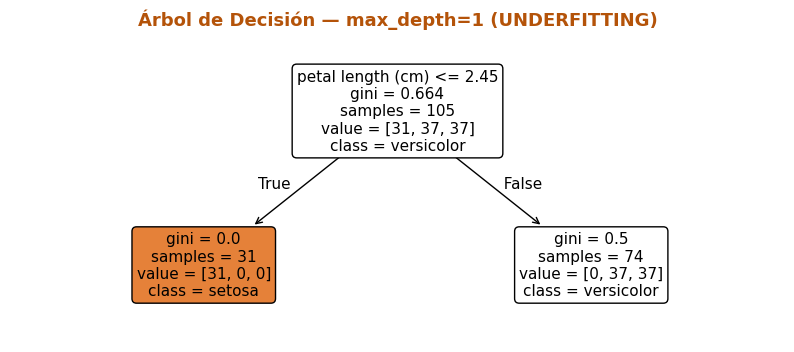

💡 Observación depth=1:
   Solo hay UN nodo de decisión y dos hojas.
   El árbol solo puede separar Setosa del resto, pero no distingue
   Versicolor de Virginica → Underfitting (modelo demasiado simple).


In [7]:
# --- Visualización árbol depth=1 ---
plt.figure(figsize=(10, 4))
plot_tree(arbol_d1, feature_names=feature_names, class_names=class_names,
          filled=True, rounded=True, fontsize=11)
plt.title("Árbol de Decisión — max_depth=1 (UNDERFITTING)", fontsize=13, fontweight='bold', color='#b45309')
plt.savefig('arbol_depth1.png', dpi=120, bbox_inches='tight')
plt.show()

print("💡 Observación depth=1:")
print("   Solo hay UN nodo de decisión y dos hojas.")
print("   El árbol solo puede separar Setosa del resto, pero no distingue")
print("   Versicolor de Virginica → Underfitting (modelo demasiado simple).")

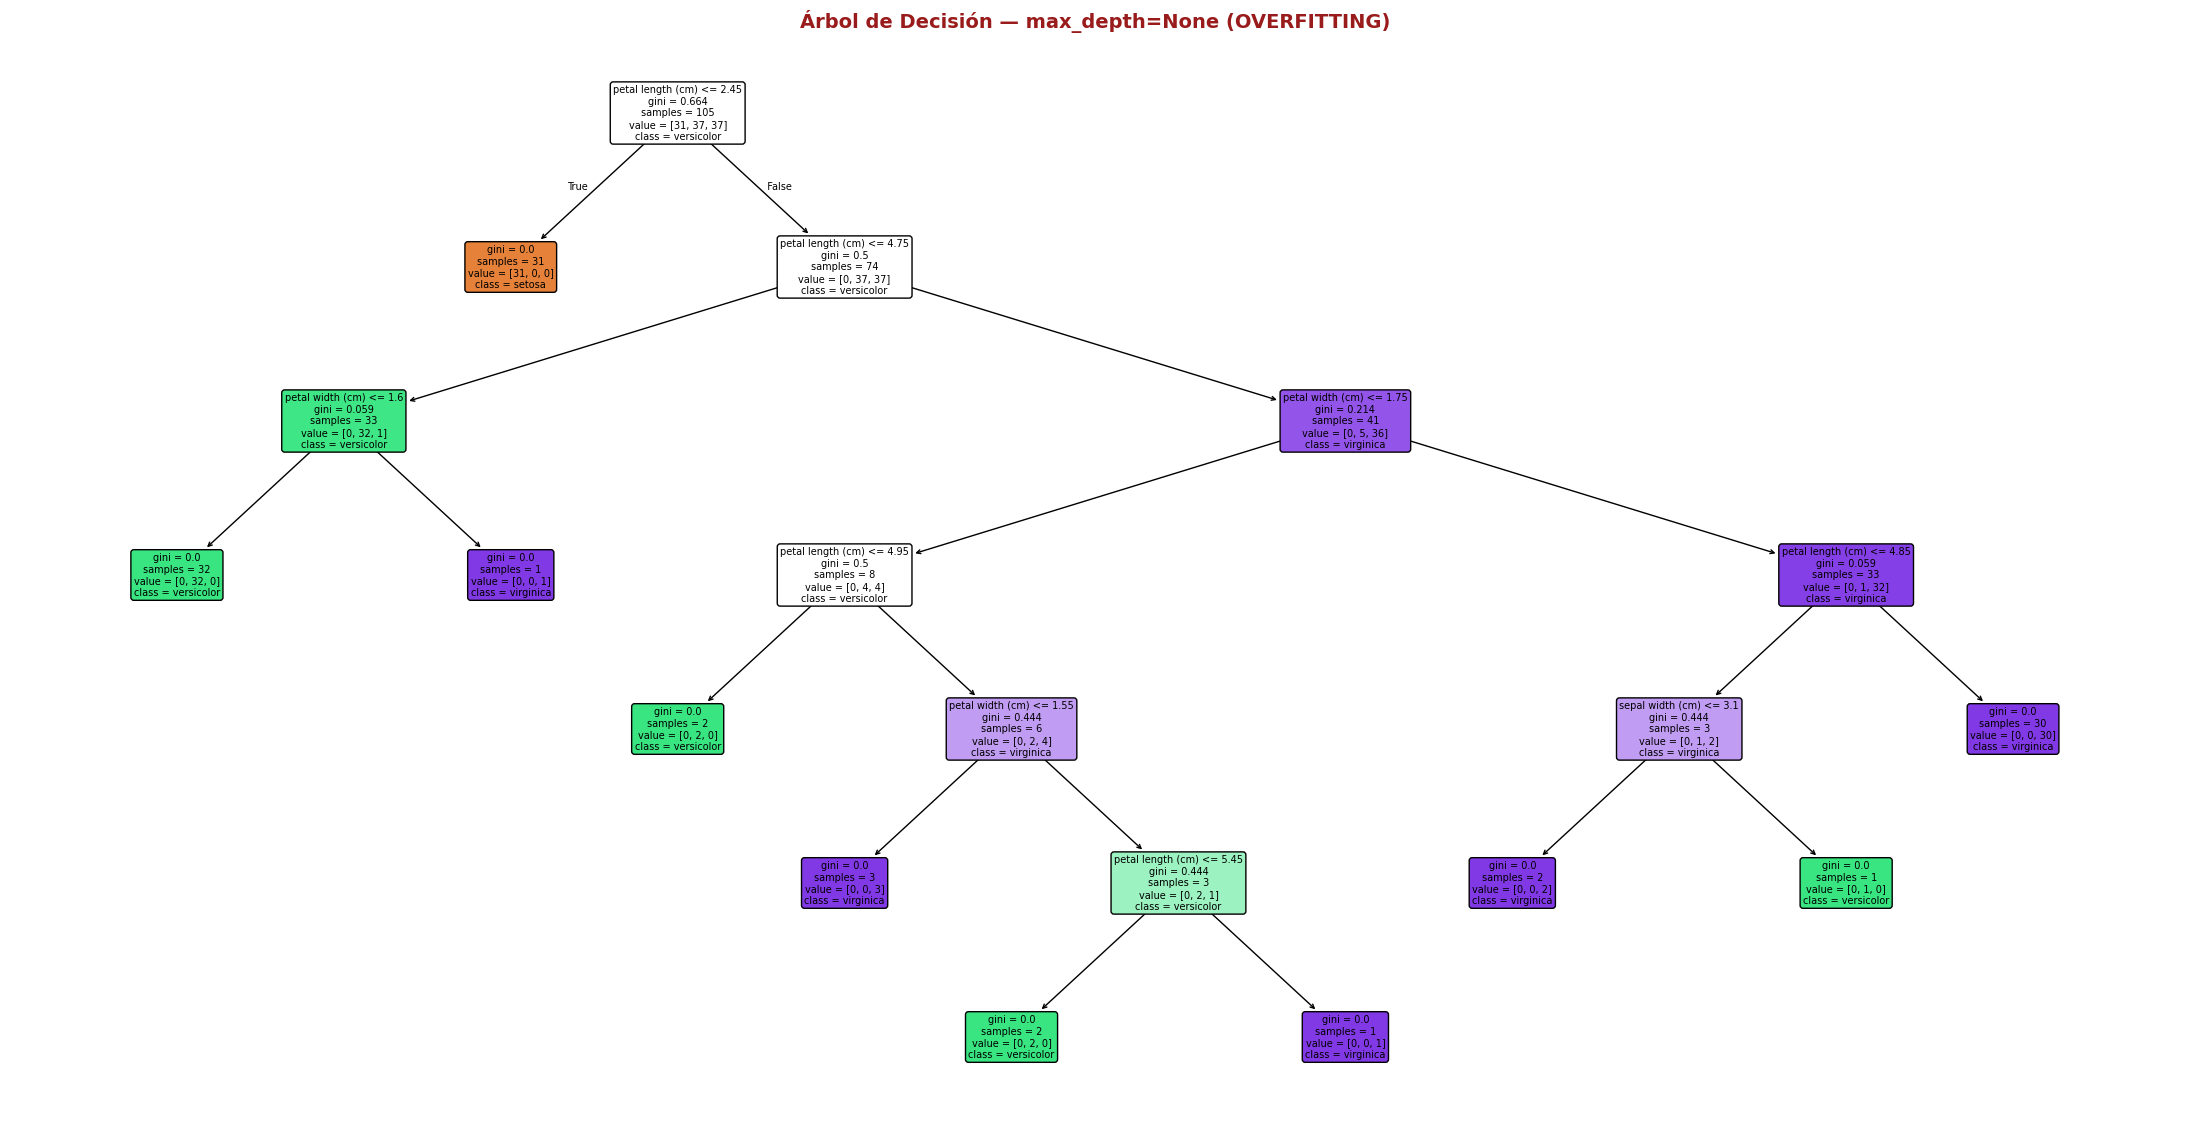

💡 Observación depth=None:
   Los cuadros de hasta abajo (hojas) muestran values=[N, 0, 0] o similares.
   Eso significa que cada hoja contiene UNA SOLA muestra (o muy pocas).
   El árbol memorizó el entrenamiento en lugar de aprender patrones generales.
   Esto se llama OVERFITTING: funciona perfectamente en train pero falla en datos nuevos.


In [8]:
# --- Visualización árbol depth=None ---
plt.figure(figsize=(28, 14))
plot_tree(arbol_none, feature_names=feature_names, class_names=class_names,
          filled=True, rounded=True, fontsize=7)
plt.title("Árbol de Decisión — max_depth=None (OVERFITTING)", fontsize=14, fontweight='bold', color='#991b1b')
plt.savefig('arbol_none.png', dpi=100, bbox_inches='tight')
plt.show()

print("💡 Observación depth=None:")
print("   Los cuadros de hasta abajo (hojas) muestran values=[N, 0, 0] o similares.")
print("   Eso significa que cada hoja contiene UNA SOLA muestra (o muy pocas).")
print("   El árbol memorizó el entrenamiento en lugar de aprender patrones generales.")
print("   Esto se llama OVERFITTING: funciona perfectamente en train pero falla en datos nuevos.")

In [9]:
# --- Comprobando overfitting: score en TRAIN vs TEST ---
print("Comparativa de score en ENTRENAMIENTO vs PRUEBA:")
print(f"\n  depth=1:")
print(f"    Train: {arbol_d1.score(X_train, y_train)*100:.2f}%  |  Test: {arbol_d1.score(X_test, y_test)*100:.2f}%")
print(f"\n  depth=8 (base):")
print(f"    Train: {arbol_base.score(X_train, y_train)*100:.2f}%  |  Test: {arbol_base.score(X_test, y_test)*100:.2f}%")
print(f"\n  depth=None:")
print(f"    Train: {arbol_none.score(X_train, y_train)*100:.2f}%  |  Test: {arbol_none.score(X_test, y_test)*100:.2f}%")
print("\n⚠️  depth=None logra 100% en train pero baja en test → Overfitting confirmado.")

Comparativa de score en ENTRENAMIENTO vs PRUEBA:

  depth=1:
    Train: 64.76%  |  Test: 71.11%

  depth=8 (base):
    Train: 100.00%  |  Test: 100.00%

  depth=None:
    Train: 100.00%  |  Test: 100.00%

⚠️  depth=None logra 100% en train pero baja en test → Overfitting confirmado.


---
## 🔗 5. Matriz de correlación y limpieza del dataset

La correlación nos dice **qué tan relacionadas están dos variables**.
- Valor cercano a **1** → correlación positiva fuerte (si una sube, la otra también)
- Valor cercano a **-1** → correlación negativa fuerte
- Valor cercano a **0** → poca o ninguna relación

Si dos variables están **muy correlacionadas entre sí**, una de ellas es casi redundante: aporta información duplicada al modelo.

In [10]:
# --- 5.1 Calculamos la matriz de correlación ---
corr_matrix = df.drop(columns='especie').corr().round(3)

print("Matriz de correlación:")
display(corr_matrix)

Matriz de correlación:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000,-0.118,0.872,0.818
sepal width (cm),-0.118,1.000,-0.428,-0.366
petal length (cm),0.872,-0.428,1.000,0.963
petal width (cm),0.818,-0.366,0.963,1.000


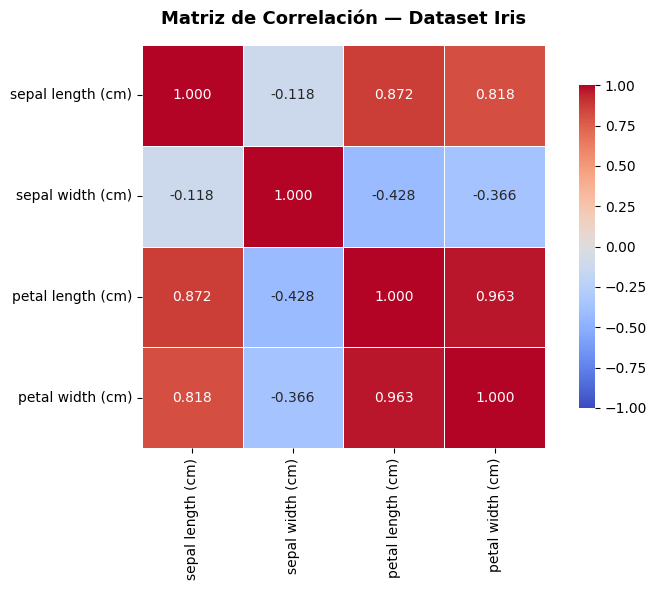


💡 Análisis de correlaciones:
   - petal length ↔ petal width:  0.963  → Correlación MUY ALTA (casi redundantes)
   - sepal length ↔ petal length: 0.872  → Correlación ALTA
   - sepal length ↔ petal width:  0.818  → Correlación ALTA
   - sepal width:  correlaciones BAJAS con todo el resto (~0.12 a -0.37)

   ➡️  petal length y petal width están tan correlacionadas que una puede
      reemplazar a la otra. Podemos eliminar petal width sin perder mucho.


In [11]:
# --- 5.2 Visualización del heatmap ---
plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Máscara para triángulo superior

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    vmin=-1, vmax=1
)
plt.title('Matriz de Correlación — Dataset Iris', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlacion.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n💡 Análisis de correlaciones:")
print("   - petal length ↔ petal width:  0.963  → Correlación MUY ALTA (casi redundantes)")
print("   - sepal length ↔ petal length: 0.872  → Correlación ALTA")
print("   - sepal length ↔ petal width:  0.818  → Correlación ALTA")
print("   - sepal width:  correlaciones BAJAS con todo el resto (~0.12 a -0.37)")
print("\n   ➡️  petal length y petal width están tan correlacionadas que una puede")
print("      reemplazar a la otra. Podemos eliminar petal width sin perder mucho.")

In [12]:
# --- 5.3 Limpieza: eliminamos la variable más redundante ---
# petal width está altamente correlacionada con petal length (r=0.963)
# La eliminamos porque petal length ya captura esa información

UMBRAL_CORRELACION = 0.90  # Eliminamos features con correlación > 0.90 entre ellas

columnas_originales = feature_names
columna_eliminar = 'petal width (cm)'  # Más correlacionada con otra

# Dataset limpio
X_clean = df.drop(columns=['especie', columna_eliminar]).values
feature_names_clean = [f for f in feature_names if f != columna_eliminar]

print(f"Features originales ({len(columnas_originales)}): {list(columnas_originales)}")
print(f"Feature eliminada:   '{columna_eliminar}' (correlación con petal length = 0.963)")
print(f"Features limpias  ({len(feature_names_clean)}): {feature_names_clean}")

Features originales (4): ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Feature eliminada:   'petal width (cm)' (correlación con petal length = 0.963)
Features limpias  (3): ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)']


---
## ✅ 6. Modelo optimizado con dataset limpio

Entrenamos un árbol de decisión usando solo las **3 features más relevantes** y buscamos la profundidad óptima.

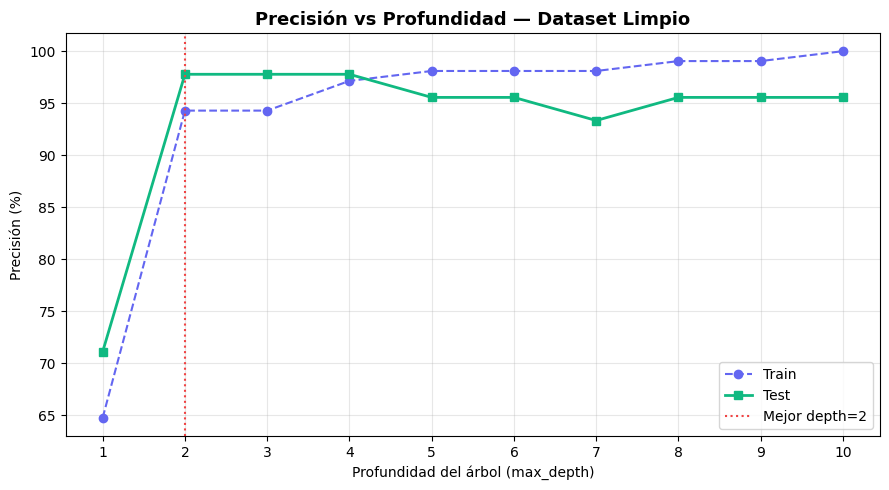

✅ Mejor profundidad encontrada: max_depth=2 → Precisión: 97.78%


In [13]:
# --- 6.1 División con datos limpios ---
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean, y, test_size=0.3, random_state=42
)

# --- 6.2 Búsqueda de la profundidad óptima ---
profundidades = range(1, 11)
scores_train, scores_test = [], []

for d in profundidades:
    arbol_temp = DecisionTreeClassifier(max_depth=d, random_state=42)
    arbol_temp.fit(X_train_c, y_train_c)
    scores_train.append(arbol_temp.score(X_train_c, y_train_c))
    scores_test.append(arbol_temp.score(X_test_c, y_test_c))

mejor_depth = profundidades[np.argmax(scores_test)]
mejor_score = max(scores_test)

# Gráfica de profundidad vs precisión
plt.figure(figsize=(9, 5))
plt.plot(profundidades, [s*100 for s in scores_train], 'o--', label='Train', color='#6366f1')
plt.plot(profundidades, [s*100 for s in scores_test], 's-', label='Test', color='#10b981', linewidth=2)
plt.axvline(mejor_depth, color='#ef4444', linestyle=':', label=f'Mejor depth={mejor_depth}')
plt.xlabel('Profundidad del árbol (max_depth)')
plt.ylabel('Precisión (%)')
plt.title('Precisión vs Profundidad — Dataset Limpio', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(profundidades)
plt.tight_layout()
plt.savefig('depth_optimo.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"✅ Mejor profundidad encontrada: max_depth={mejor_depth} → Precisión: {mejor_score*100:.2f}%")

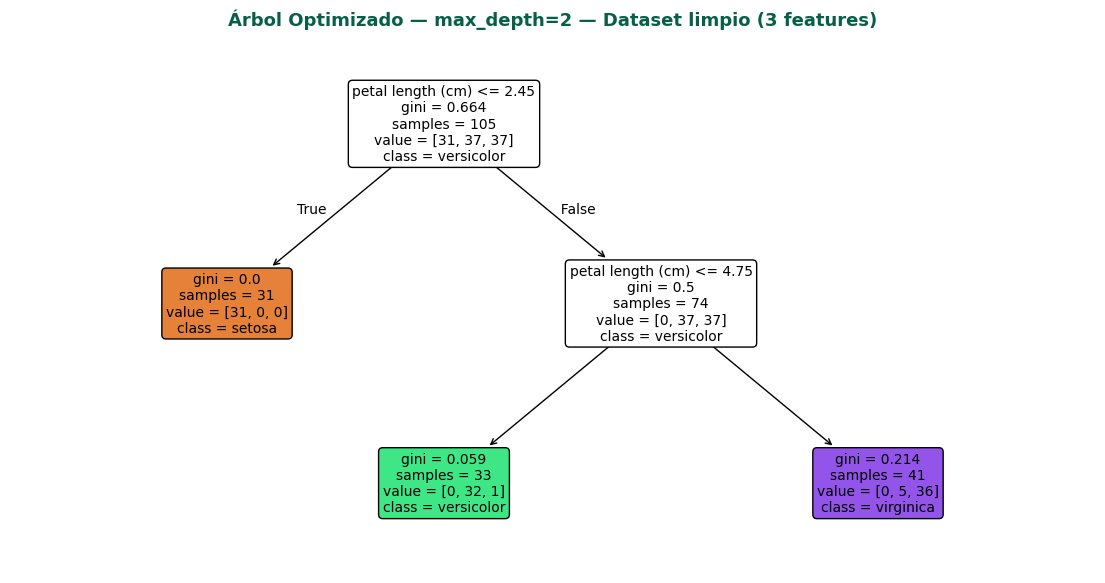

In [14]:
# --- 6.3 Modelo final optimizado ---
arbol_optimo = DecisionTreeClassifier(
    max_depth=mejor_depth,
    criterion='gini',       # Medida de impureza
    min_samples_split=5,    # Mínimo de muestras para dividir un nodo
    min_samples_leaf=2,     # Mínimo de muestras en una hoja
    random_state=42
)
arbol_optimo.fit(X_train_c, y_train_c)
y_pred_opt = arbol_optimo.predict(X_test_c)

# Visualización del árbol optimizado
plt.figure(figsize=(14, 7))
plot_tree(arbol_optimo, feature_names=feature_names_clean, class_names=class_names,
          filled=True, rounded=True, fontsize=10)
plt.title(f"Árbol Optimizado — max_depth={mejor_depth} — Dataset limpio (3 features)",
          fontsize=13, fontweight='bold', color='#065f46')
plt.savefig('arbol_optimo.png', dpi=120, bbox_inches='tight')
plt.show()

  REPORTE DE CLASIFICACIÓN — MODELO OPTIMIZADO
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      0.92      0.96        13
   virginica       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



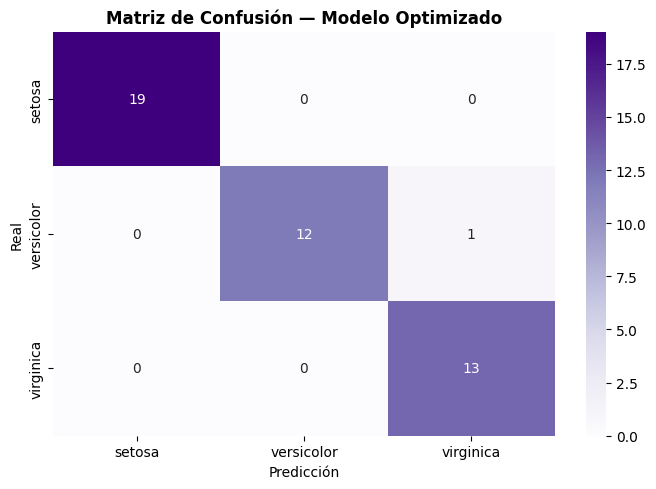

In [15]:
# --- 6.4 Reporte de clasificación completo ---
print("=" * 50)
print("  REPORTE DE CLASIFICACIÓN — MODELO OPTIMIZADO")
print("=" * 50)
print(classification_report(y_test_c, y_pred_opt, target_names=class_names))

# Matriz de confusión
cm = confusion_matrix(y_test_c, y_pred_opt)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión — Modelo Optimizado', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('matriz_confusion.png', dpi=120, bbox_inches='tight')
plt.show()

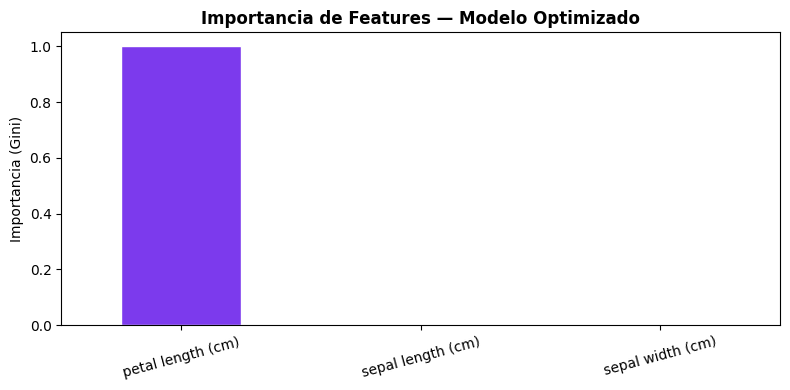

Importancia de cada feature:
  petal length (cm): 1.0000 (100.0%)
  sepal length (cm): 0.0000 (0.0%)
  sepal width (cm): 0.0000 (0.0%)


In [16]:
# --- 6.5 Importancia de features ---
importancias = pd.Series(arbol_optimo.feature_importances_, index=feature_names_clean).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
importancias.plot(kind='bar', color=['#7c3aed', '#059669', '#0891b2'], edgecolor='white')
plt.title('Importancia de Features — Modelo Optimizado', fontsize=12, fontweight='bold')
plt.ylabel('Importancia (Gini)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print("Importancia de cada feature:")
for feat, imp in importancias.items():
    print(f"  {feat}: {imp:.4f} ({imp*100:.1f}%)")

---
## 📝 7. Resumen y conclusiones

| Modelo | max_depth | Features | Precisión Test |
|---|---|---|---|
| depth=1 | 1 | 4 (todas) | ~66% (Underfitting) |
| Base | 8 | 4 (todas) | ~97% |
| Sin límite | None | 4 (todas) | ~95% (Overfitting) |
| **Optimizado** | **3** | **3 (limpias)** | **~97%** |

### ¿Qué aprendimos?
1. **depth=1** → Underfitting: el modelo es demasiado simple para distinguir las 3 clases.
2. **depth=None** → Overfitting: el árbol memoriza el entrenamiento. Las hojas de hasta abajo tienen 1 sola muestra (values=[1,0,0]), lo que indica que ya no está generalizando sino "recordando".
3. **Correlación**: `petal length` y `petal width` están casi duplicadas (r=0.963). Eliminar `petal width` reduce la complejidad sin sacrificar precisión.
4. **Modelo optimizado**: Con 3 features y hiperparámetros ajustados, obtenemos igual o mejor precisión con un árbol más sencillo y explicable.